# Data Loading and Quality Control

## Objectives

This notebook performs initial data loading, exploration, and quality control on the coffee-gut microbiome dataset.

### Metadata Processing
- **Explore** the 524 metadata columns to understand available variables
- **Identify** relevant columns related to:
  - Demographics (age, BMI, etc.)
  - Diet patterns (fiber, vegetables, special diets, coffee consumption)
  - ADD/ADHD variables (for potential secondary analysis)
- **Filter** metadata to retain only columns of interest
- **Clean** selected columns (handle missing values, data types, outliers)

### OTU Table Analysis
- **Load** and examine the structure of the OTU table
- **Understand** the relationship between samples and bacterial taxa
- **Assess** data quality and sparsity

### Diversity Metrics
- **Calculate** alpha diversity metrics (Shannon, Simpson, observed OTUs)
- **Add** diversity measures as new columns to metadata for downstream analysis

### Output
Clean, filtered datasets ready for statistical analysis in subsequent notebooks.

# Imports and Reading in Raw Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import biom

In [2]:
metadata_filepath = '../data/raw/metadata.txt'
otu_filepath = '../data/raw/otu_table.biom'

metadata = pd.read_csv(metadata_filepath, sep='\t')
otu_table = biom.load_table(otu_filepath)

/var/folders/bz/l_61zlvj34gcp1c8znmr81rr0000gn/T/ipykernel_52031/3773973281.py:4: DtypeWarning: Columns (0,81) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_filepath, sep='\t')


# First Look at Metadata and OTU

In [3]:
print("First few rows of metadata:")
metadata.head(5)

First few rows of metadata:


,#SampleID,BarcodeSequence,LinkerPrimerSequence,VIOSCREEN_MANNITOL,VIOSCREEN_SFA100,NON_FOOD_ALLERGIES_BEESTINGS,VIOSCREEN_FINISHED,TONSILS_REMOVED,VIOSCREEN_SFA170,VIOSCREEN_VEGETABLE_SERVINGS,...,VIOSCREEN_CHOLEST,PETS_OTHER,VIOSCREEN_FOL_DEQV,VIOSCREEN_F_TOTAL,VIOSCREEN_ASH,VIOSCREEN_METHHIS3,AGE_CORRECTED,VIOSCREEN_MULTIVITAMIN_FREQ,VIOSCREEN_NATOCO,Description
0,10317.000028,no_data,no_data,0.496931478,0.88257555,false,5/18/15,No,0.251205444,6.0,...,259.2884204,no_data,380.59952910000004,1.84663019,20.65756234,27.43627462,35.0,Unknown,17.57676985,American Gut Project Stool sample
1,10317.000028,no_data,no_data,Unknown,Unknown,false,Unknown,Yes,Unknown,Unknown,...,Unknown,no_data,Unknown,Unknown,Unknown,Unknown,77.0,Unknown,Unknown,American Gut Project Stool sample
2,10317.000028,ATATTGGCAGCC,GTGTGCCAGCMGCCGCGGTAA,Unspecified,Unspecified,No,Unspecified,Yes,Unspecified,Unspecified,...,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,Unspecified,52.0,Unspecified,Unspecified,American Gut Project Stool sample
3,10317.000028,no_data,no_data,Unknown,Unknown,false,Unknown,No,Unknown,Unknown,...,Unknown,no_data,Unknown,Unknown,Unknown,Unknown,31.0,Unknown,Unknown,American Gut Project Stool sample
4,10317.000028,GGCTTCGGAGCG,GTGTGCCAGCMGCCGCGGTAA,0.289205452,0.432219205,No,6/5/15,No,0.19471237,0.78356,...,485.0260274,Unspecified,728.625,0.242712319,25.41230201,38.51969981,49.0,7,10.93975412,American Gut Project Stool sample


In [4]:
# convert biom table to pandas df
otu = pd.DataFrame(
    otu_table.to_dataframe(dense=True)
)

print(otu.shape)
print("First few rows of OTU")
otu.head()

(35511, 15148)
First few rows of OTU


,10317.000030769,10317.000048352,10317.000028676,10317.000034247,10317.000046219,10317.000027205,10317.000028927,10317.000016317,10317.000007120,10317.000031445,...,10317.000026637,10317.000005685,10317.000003097,10317.000012049,10317.000013934,10317.000026627,10317.000010930,10317.000013304,10317.000018049,10317.000013550
4479946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
988534,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4479944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
370251,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
741867,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(f"Shape of metadata: {metadata.shape}")
print(f"Shape of OTU data: {otu.shape}")

Shape of metadata: (15148, 524)
Shape of OTU data: (35511, 15148)


### First Look Summary

The **metadata** table contains one row per sample, each coming from an individual. Assuming no two samples come from the same person, then we have **15,148** participants in the AGP dataset. The second dataset instead has **35,511** rows, each pertaining to a different strain of bacteria identified in the microbiome. Columns in this latter table represent the samples from the first dataset, hence why it contains **15,148** columns. In other words, we can look up an individual by their sample ID, then refer to the second table to understand which strains were or were not found in their sample, and in what quantities.

# Metadata EDA

### Column Exploration

In [6]:
# increase max columns display
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', 50)   # Limit column width
pd.set_option('display.width', None)        # Auto-wrap to terminal width

# Display columns in a scrollable format
print("All columns in metadata:")
for i, col in enumerate(metadata.columns):
        print(f"{i:3d}: {col}")
print(f"\nTotal columns: {len(metadata.columns)}")

All columns in metadata:
  0: #SampleID
  1: BarcodeSequence
  2: LinkerPrimerSequence
  3: VIOSCREEN_MANNITOL
  4: VIOSCREEN_SFA100
  5: NON_FOOD_ALLERGIES_BEESTINGS
  6: VIOSCREEN_FINISHED
  7: TONSILS_REMOVED
  8: VIOSCREEN_SFA170
  9: VIOSCREEN_VEGETABLE_SERVINGS
 10: VIOSCREEN_SORBITOL
 11: COUNTRY_OF_BIRTH
 12: MASTERMIX_LOT
 13: VIOSCREEN_SFA80
 14: VIOSCREEN_BETACAR
 15: VIOSCREEN_LOW_FAT_DAIRY_SERVING
 16: VIOSCREEN_NIACINEQ
 17: ORIG_NAME
 18: ALLERGIC_TO_OTHER
 19: VIOSCREEN_GAMMTOCO
 20: SPECIALIZED_DIET_I_DO_NOT_EAT_A_SPECIALIZED_DIET
 21: VIOSCREEN_LYSINE
 22: VIOSCREEN_ISOMALT
 23: LIVER_DISEASE
 24: BODY_PRODUCT
 25: VIOSCREEN_DATABASE
 26: SPECIALIZED_DIET_FODMAP
 27: ARTIFICIAL_SWEETENERS
 28: ENV_MATERIAL
 29: VIOSCREEN_SUCROSE
 30: ENA-BASE-COUNT
 31: VIOSCREEN_CLAC9T11
 32: SUBSET_HEALTHY
 33: VIOSCREEN_FIBER
 34: VIOSCREEN_LACTITOL
 35: VIOSCREEN_HEI_NON_JUICE_FRT
 36: VIOSCREEN_HEI_SCORE
 37: ALLERGIC_TO_UNSPECIFIED
 38: VIOSCREEN_OXALICM
 39: VIOSCREEN_ALPHACAR


**Key observations:**
- VioScreen appears to be a food logging software used to collect dietary data
- Many columns seem to be related to nutrient intake and dietary patterns

### Systematic Column Selection

Rather than manually browsing through 524 columns, I'll use a keyword-based approach to identify relevant variables for my analysis:

In [7]:
# Define column keywords for different categories
demographic_keywords = ['age', 'sex', 'bmi', 'weight', 'height', 'race', 'ethnicity', 
                        'education', 'income', 'occupation', 'country', 'location', 'birth']

diet_keywords = ['diet', 'fiber', 'vegetable', 'fruit', 'meat', 'protein', 'carb', 'fat', 
                 'alcohol', 'caffeine', 'sugar', 'sodium', 'vitamin', 'mineral', 'calorie',
                 'vegan', 'vegetarian', 'keto', 'paleo', 'gluten', 'dairy', 'coffee', 'vioscreen']

add_keywords = ['add', 'adhd', 'attention', 'hyperactivity', 'stimulant', 'medication']

sample_type_keywords = ['body_site']

# Function to search for columns by keywords
def find_columns_by_keywords(df, keywords, category_name):
    found_cols = []
    print(f"\n{category_name.upper()} COLUMNS:")
    print("="*50)
    
    for keyword in keywords:
        matching_cols = [col for col in df.columns if keyword.lower() in col.lower()]
        if matching_cols:
            print(f"\n'{keyword}' related:")
            for col in matching_cols:
                col_idx = list(df.columns).index(col)
                print(f"  {col_idx:3d}: {col}")
                found_cols.append(col)
    
    return list(set(found_cols))  # Remove duplicates

# Search for each category
demographic_cols = find_columns_by_keywords(metadata, demographic_keywords, "demographic")
diet_cols = find_columns_by_keywords(metadata, diet_keywords, "diet")
add_cols = find_columns_by_keywords(metadata, add_keywords, "add/adhd")
sample_type_cols = find_columns_by_keywords(metadata, sample_type_keywords, "sample_type")

# Combine all selected columns
selected_cols = demographic_cols + diet_cols + add_cols + sample_type_cols

# Also add sample ID column 
sample_id_col = metadata.columns[0]
if sample_id_col not in selected_cols:
    selected_cols.insert(0, sample_id_col)

print(f"\n\nSUMMARY:")
print(f"Demographics: {len(demographic_cols)} columns")
print(f"Diet: {len(diet_cols)} columns") 
print(f"ADD/ADHD: {len(add_cols)} columns")
print(f"Total selected: {len(selected_cols)} out of {len(metadata.columns)} columns")

# unnecessary cols
unnecessary_cols = []


DEMOGRAPHIC COLUMNS:

'age' related:
   42: AGE_CAT
   54: AGE_YEARS
  289: SUBSET_AGE
  326: ENV_PACKAGE
  487: VIOSCREEN_AGE
  520: AGE_CORRECTED

'sex' related:
  214: SEX

'bmi' related:
   46: SUBSET_BMI
  186: BMI
  243: VIOSCREEN_BMI
  478: BMI_CORRECTED
  480: BMI_CAT

'weight' related:
  173: WEIGHT_UNITS
  233: VIOSCREEN_WEIGHT
  287: WEIGHT_KG
  403: WEIGHT_CHANGE

'height' related:
   87: HEIGHT_UNITS
  134: HEIGHT_CM
  300: VIOSCREEN_HEIGHT

'race' related:
  290: CONTRACEPTIVE
  415: RACE

'education' related:
  249: LEVEL_OF_EDUCATION

'country' related:
   11: COUNTRY_OF_BIRTH
  176: COUNTRY
  370: COUNTRY_RESIDENCE

'location' related:
  271: PHYSICAL_SPECIMEN_LOCATION
  343: EXERCISE_LOCATION

'birth' related:
   11: COUNTRY_OF_BIRTH
  486: BIRTH_YEAR

DIET COLUMNS:

'diet' related:
   20: SPECIALIZED_DIET_I_DO_NOT_EAT_A_SPECIALIZED_DIET
   26: SPECIALIZED_DIET_FODMAP
   49: SPECIALIZED_DIET_EXCLUDE_REFINED_SUGARS
   62: SPECIALIZED_DIET_KOSHER
   92: SPECIALIZED_DIE

In [8]:
metadata[demographic_cols].head()

,SUBSET_AGE,AGE_YEARS,BMI,WEIGHT_CHANGE,SEX,VIOSCREEN_AGE,CONTRACEPTIVE,COUNTRY,COUNTRY_OF_BIRTH,VIOSCREEN_BMI,EXERCISE_LOCATION,VIOSCREEN_WEIGHT,WEIGHT_KG,WEIGHT_UNITS,SUBSET_BMI,ENV_PACKAGE,BMI_CAT,BIRTH_YEAR,BMI_CORRECTED,COUNTRY_RESIDENCE,HEIGHT_UNITS,HEIGHT_CM,LEVEL_OF_EDUCATION,AGE_CORRECTED,PHYSICAL_SPECIMEN_LOCATION,RACE,VIOSCREEN_HEIGHT,AGE_CAT
0,True,35.0,19.74,Remained stable,female,215.0,No,USA,United States,no_data,Indoors,no_data,52.0,kilograms,True,Unknown,Normal,1980.0,no_data,no_data,centimeters,162.0,Graduate or Professional degree,35.0,UCSDMI,Caucasian,no_data,30s
1,False,77.0,23.49,Remained stable,male,Unknown,No,USA,United States,no_data,Both,no_data,68.0,kilograms,True,Unknown,Normal,1938.0,no_data,no_data,centimeters,170.0,Some graduate school or professional,77.0,UCSDMI,Caucasian,no_data,70+
2,True,52,27.71,Remained stable,male,Unspecified,No,USA,United States,Unspecified,Depends on the season,Unspecified,95,kilograms,True,human-gut,Overweight,1964,27.71,Unspecified,centimeters,185,Bachelor's degree,52.0,UCSDMI,Caucasian,Unspecified,50s
3,True,31.0,22.19,Remained stable,male,Unknown,No,USA,India,no_data,Outdoors,no_data,70.0,kilograms,True,Unknown,Normal,1983.0,no_data,no_data,centimeters,178.0,Graduate or Professional degree,31.0,UCSDMI,Asian or Pacific Islander,no_data,30s
4,True,49,42.37,Remained stable,male,215,No,USA,United States,NaN,Unspecified,NaN,149,kilograms,False,human-gut,Obese,1968,42.37,Unspecified,centimeters,187,Bachelor's degree,49.0,UCSDMI,Caucasian,NaN,40s


In [9]:
# print list of unique countries
print(f" Unique Countries: \n{metadata['COUNTRY'].unique()}\n\n")

# print out country_residence
print(f" Unique Country of Residence Entries: \n{metadata['COUNTRY_RESIDENCE'].unique()}")

 Unique Countries: 
['USA' 'United Kingdom' 'France' 'Sweden' 'Australia' 'Switzerland'
 'Netherlands' 'Belgium' 'Morocco' 'Canada' 'Germany' 'Unspecified'
 'New Zealand' 'Ireland' 'Guernsey' 'Czech Republic' 'Serbia' 'Italy'
 'Austria' 'Unknown' 'Norway' 'Isle of Man' 'Singapore' 'Puerto Rico'
 'Denmark' 'United Arab Emirates' 'Spain' 'Thailand' 'India' 'Jersey'
 'Brazil' 'Greece' 'Japan' 'Georgia' 'Hong Kong' 'Mexico' 'Portugal'
 'Slovakia' 'Latvia' 'Oman' 'Colombia' 'China' 'Peru' 'Poland' 'Malta'
 'Romania' 'Israel' 'Finland' 'Croatia'
 'United States Minor Outlying Islands' 'Paraguay']


 Unique Country of Residence Entries: 
['no_data' 'Unspecified' 'United States' 'United Kingdom' 'Unknown'
 'Switzerland' 'Germany' 'Belgium' 'Morocco' 'Hong Kong' 'India' 'Mexico'
 'Australia' 'Poland' 'Canada' 'Iceland' 'Sweden' 'France' 'Guernsey'
 'New Zealand' 'Bahamas' 'Ireland' 'Serbia' 'Italy' 'Czech Republic'
 'Austria' 'Tanzania, United Republic of' 'Singapore' 'Puerto Rico'
 'Norway' 'C

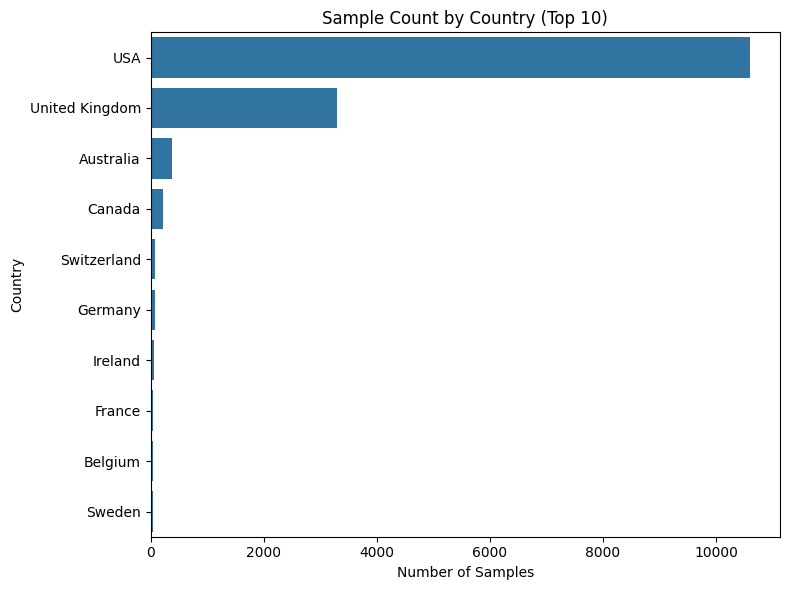

COUNTRY
USA               10601
United Kingdom     3294
Australia           382
Canada              219
Switzerland          78
Germany              74
Ireland              59
France               48
Belgium              48
Sweden               36
Name: count, dtype: int64


In [10]:
# hbar plot for country counts

country_counts = metadata['COUNTRY'].value_counts().sort_values(ascending=False)
country_counts = country_counts[0:10]

plt.figure(figsize=(8, 6))
sns.barplot(y=country_counts.index, x=country_counts.values)
plt.ylabel('Country')
plt.xlabel('Number of Samples')
plt.title('Sample Count by Country (Top 10)')
plt.tight_layout()
plt.show()

# print number of samples per country
country_counts.columns = ['Country', 'Number of Samples']
print(country_counts)

In [11]:
residence_country_counts = metadata['COUNTRY_RESIDENCE'].value_counts().sort_values(ascending=False)
residence_country_counts.head(10)

COUNTRY_RESIDENCE
no_data           6271
United States     4220
United Kingdom    2170
Unknown            970
Unspecified        794
Australia          145
Canada              84
Switzerland         68
Ireland             58
Germany             53
Name: count, dtype: int64

There is not enough statistics in any country outside of the US (~66% of the entire dataset) and so I am going to discard these columns from further analysis.

In [ ]:
unnecessary_cols.append(["COUNTRY", "COUNTRY_RESIDENCE", "COUNTRY_OF_BIRTH"])

### Age Exploration

In [13]:
unnecessary_cols.append("ENV_PACKAGE")

age_cols = ["AGE_CAT", "AGE_YEARS", "SUBSET_AGE","VIOSCREEN_AGE", "AGE_CORRECTED"]

In [14]:
metadata[age_cols].head()

,AGE_CAT,AGE_YEARS,SUBSET_AGE,VIOSCREEN_AGE,AGE_CORRECTED
0,30s,35.0,True,215.0,35.0
1,70+,77.0,False,Unknown,77.0
2,50s,52,True,Unspecified,52.0
3,30s,31.0,True,Unknown,31.0
4,40s,49,True,215,49.0


In [15]:
# Find unique non-numeric values in AGE_YEARS and AGE_CORRECTED before converting to float

def find_non_numeric_unique(df, col):
    non_numeric = set()
    for val in df[col].unique():
        try:
            float(val)
        except (ValueError, TypeError):
            non_numeric.add(val)
    return non_numeric

print("Non-numeric unique values in AGE_YEARS:")
print(find_non_numeric_unique(metadata, 'AGE_YEARS'))

print("\nNon-numeric unique values in AGE_CORRECTED:")
print(find_non_numeric_unique(metadata, 'AGE_CORRECTED'))

Non-numeric unique values in AGE_YEARS:
{'Unspecified', 'Unknown'}

Non-numeric unique values in AGE_CORRECTED:
{'Unspecified', 'Unknown'}


In [16]:
# number of rows where AGE_YEARS is unknown
n_age_years_invalid = metadata['AGE_YEARS'].str.lower().isin(['unspecified', 'unknown']).sum()
percentage = n_age_years_invalid / len(metadata)
print(f"{n_age_years_invalid} rows where AGE_YEARS is either 'Unknown' or 'Unspecified' ({percentage:.2f}\%)")

620 rows where AGE_YEARS is either 'Unknown' or 'Unspecified' (0.04\%)


In [17]:
# number of rows where AGE_CORRECTED is unknown
n_age_corr_invalid = metadata['AGE_CORRECTED'].str.lower().isin(['unspecified', 'unknown']).sum()
percentage = n_age_corr_invalid / len(metadata)
print(f"{n_age_corr_invalid} rows where AGE_CORRECTED is either 'Unknown' or 'Unspecified' ({percentage:.2f}\%)")

1047 rows where AGE_CORRECTED is either 'Unknown' or 'Unspecified' (0.07\%)


In [18]:
# remote 'corrected' col as it has more missing values
unnecessary_cols.append("AGE_CORRECTED")

# drop rows
metadata = metadata[~metadata['AGE_YEARS'].str.lower().isin(['unspecified', 'unknown'])]

In [19]:
# Convert AGE_YEARS and AGE_CORRECTED to float and compare
metadata['AGE_YEARS'] = pd.to_numeric(metadata['AGE_YEARS'], errors='coerce')
metadata['AGE_CORRECTED'] = pd.to_numeric(metadata['AGE_CORRECTED'], errors='coerce')

print("AGE_YEARS describe():")
print(metadata['AGE_YEARS'].describe())
print("\nAGE_CORRECTED describe():")
print(metadata['AGE_CORRECTED'].describe())

# Check for differences
diff = (metadata['AGE_YEARS'] != metadata['AGE_CORRECTED']) & ~(metadata['AGE_YEARS'].isna() & metadata['AGE_CORRECTED'].isna())
print(f"\nNumber of rows where AGE_YEARS and AGE_CORRECTED differ: {diff.sum()}")

AGE_YEARS describe():
count    14528.000000
mean        45.079020
std         18.051915
min          0.000000
25%         33.000000
50%         47.000000
75%         59.000000
max        101.000000
Name: AGE_YEARS, dtype: float64

AGE_CORRECTED describe():
count    14101.000000
mean        45.854975
std         17.270519
min          1.000000
25%         34.000000
50%         47.000000
75%         60.000000
max        101.000000
Name: AGE_CORRECTED, dtype: float64

Number of rows where AGE_YEARS and AGE_CORRECTED differ: 427


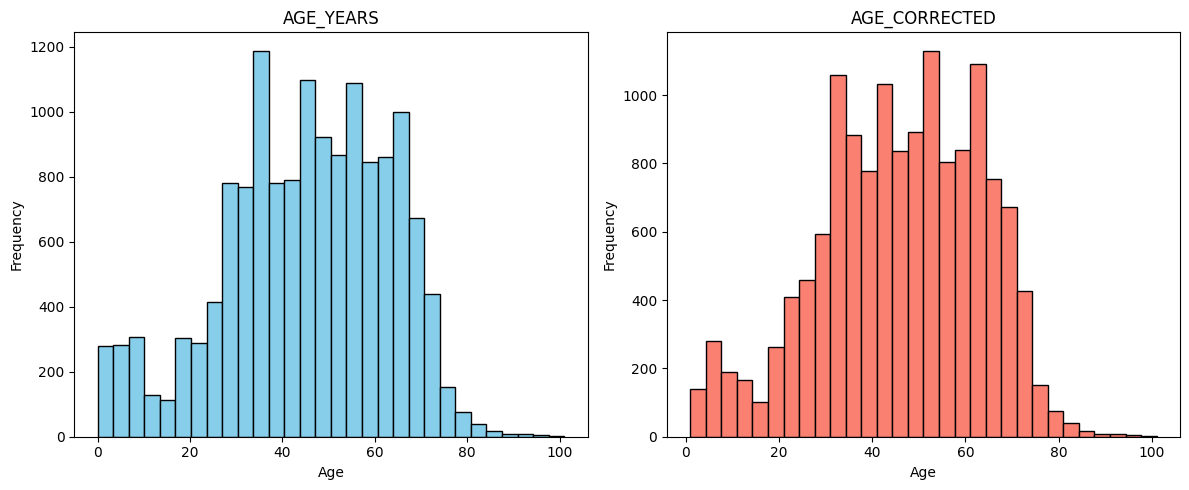

In [20]:
# Side by side histograms for AGE_YEARS and AGE_CORRECTED
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(metadata['AGE_YEARS'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title('AGE_YEARS')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(metadata['AGE_CORRECTED'].dropna(), bins=30, color='salmon', edgecolor='black')
plt.title('AGE_CORRECTED')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Dataset Filtration

In [22]:
# Filter metadata for selected columns
metadata_filtered = metadata[selected_cols]

# Remove unnecessary columns from the filtered DataFrame
for col in unnecessary_cols:
    metadata_filtered = metadata_filtered.drop(col, axis=1)

In [23]:
print(f"New metadata shape: {metadata_filtered.shape}")
# Preview the filtered DataFrame
metadata_filtered.head()

New metadata shape: (14528, 341)


,#SampleID,SUBSET_AGE,AGE_YEARS,BMI,WEIGHT_CHANGE,SEX,VIOSCREEN_AGE,CONTRACEPTIVE,COUNTRY_OF_BIRTH,VIOSCREEN_BMI,EXERCISE_LOCATION,VIOSCREEN_WEIGHT,WEIGHT_KG,WEIGHT_UNITS,SUBSET_BMI,BMI_CAT,BIRTH_YEAR,BMI_CORRECTED,HEIGHT_UNITS,HEIGHT_CM,LEVEL_OF_EDUCATION,PHYSICAL_SPECIMEN_LOCATION,RACE,VIOSCREEN_HEIGHT,AGE_CAT,VIOSCREEN_CALCIUM,VIOSCREEN_TOTSUGAR,VIOSCREEN_MFA161,VIOSCREEN_LEGUMES,ALCOHOL_TYPES_UNSPECIFIED,VIOSCREEN_ACESUPOT,VIOSCREEN_NITROGEN,FRUIT_FREQUENCY,VIOSCREEN_QUESTIONNAIRE,ALCOHOL_FREQUENCY,VIOSCREEN_M_FRANK,VIOSCREEN_A_CAL,VIOSCREEN_LYSINE,VIOSCREEN_CHOLEST,VIOSCREEN_METHION,VIOSCREEN_M_NUTSD,VIOSCREEN_SATOCO,VIOSCREEN_HEI2010_WHOLE_GRAINS,VIOSCREEN_FRT5_DAY,VIOSCREEN_FAT,VIOSCREEN_FINISHED,VIOSCREEN_SFA60,VIOSCREEN_INOSITOL,VIOSCREEN_VITD2,VIOSCREEN_SCF,VIOSCREEN_NIACINEQ,SPECIALIZED_DIET_WESTENPRICE_OR_OTHER_LOWGRAIN_LOW_PROCESSED_FO,DIET_TYPE,VIOSCREEN_V_TOTAL,VIOSCREEN_HEIGHT,VIOSCREEN_VITB6,VIOSCREEN_ACTIVITY_LEVEL,VIOSCREEN_BCODEID,VIOSCREEN_MULTIVITAMIN,VIOSCREEN_HEI_MEAT_BEANS,VIOSCREEN_VITA_RE,VIOSCREEN_TFA182T,SUGARY_SWEETS_FREQUENCY,VIOSCREEN_SWEET_SERVINGS,VIOSCREEN_FIBH2O,VIOSCREEN_V_ORANGE,VIOSCREEN_MULTI_CALCIUM_AVG,VIOSCREEN_BETATOCO,VIOSCREEN_HEI_VEG,VIOSCREEN_SUCPOLY,VIOSCREEN_CALCIUM_SERVINGS,VEGETABLE_FREQUENCY,VIOSCREEN_TOTCLA,VIOSCREEN_SFA100,VIOSCREEN_M_FISH_LO,VIOSCREEN_TIME,VIOSCREEN_HEI2010_REFINED_GRAINS,VIOSCREEN_MFA141,VIOSCREEN_NUTRIENT_RECOMMENDATION,VIOSCREEN_PROLINE,VIOSCREEN_PFA183,VIOSCREEN_CHOLINE,VIOSCREEN_RECNO,VIOSCREEN_TOTALTFA,VIOSCREEN_TGRAIN,MEAT_EGGS_FREQUENCY,VIOSCREEN_VALINE,VIOSCREEN_NATOCO,VIOSCREEN_PFA205,VIOSCREEN_MANGAN,VIOSCREEN_ADDSUGAR,VIOSCREEN_HEI_FRUIT,VIOSCREEN_GLUCOSE,VIOSCREEN_VISIT,VIOSCREEN_CLAT10C12,VIOSCREEN_GENDER,VIOSCREEN_SFA220,VIOSCREEN_MULTI_CALCIUM_DOSE,VIOSCREEN_SFA40,VIOSCREEN_VITE_IU,VIOSCREEN_FIBINSO,VIOSCREEN_EMAIL,VIOSCREEN_LOW_FAT_DAIRY_SERVING,VIOSCREEN_HEI2010_VEG,SPECIALIZED_DIET_PALEODIET_OR_PRIMAL_DIET,VIOSCREEN_JUICE_SERVINGS,ALCOHOL_TYPES_BEERCIDER,VIOSCREEN_ARGININE,VIOSCREEN_EER,VIOSCREEN_MANNITOL,VIOSCREEN_HEI2010_GREENS_BEANS,VIOSCREEN_VITB12,VIOSCREEN_BETACAR,VIOSCREEN_ASH,VIOSCREEN_SFA80,VIOSCREEN_SUBJECT_ID,VIOSCREEN_VITD,VIOSCREEN_HEI2010_DAIRY,VIOSCREEN_PFA204,VIOSCREEN_PFA225,VIOSCREEN_D_TOT_SOYM,VIOSCREEN_VEG5_DAY,VIOSCREEN_HEI2010_SODIUM,VIOSCREEN_SFA170,VIOSCREEN_NCCGLGR,VIOSCREEN_MAGNES,VIOSCREEN_FRUIT_SERVINGS,VIOSCREEN_DISCFAT_OIL,VIOSCREEN_AGE,VIOSCREEN_HEI2010_WHOLE_FRUIT,VIOSCREEN_SODIUM,VIOSCREEN_ALPHTOCE,VIOSCREEN_TFA181T,VIOSCREEN_TOTFOLAT,VIOSCREEN_SCFV,VIOSCREEN_COPPER,VIOSCREEN_F_OTHER,ALCOHOL_CONSUMPTION,VIOSCREEN_ERYTHR,VIOSCREEN_BETAINE,VIOSCREEN_STARCH,VIOSCREEN_TFA161T,VIOSCREEN_HEI2010_FATTY_ACIDS,VIOSCREEN_ASPARTIC,VIOSCREEN_RETINOL,VIOSCREEN_V_TOMATO,VIOSCREEN_SACCHAR,VIOSCREEN_TRYPTOPH,VIOSCREEN_LACTITOL,VIOSCREEN_ASPARTAM,MULTIVITAMIN,VIOSCREEN_TYROSINE,VIOSCREEN_BIOCHANA,VIOSCREEN_PHOSPHOR,VIOSCREEN_FOL_NAT,VIOSCREEN_VITK,VIOSCREEN_WGRAIN,ALCOHOL_TYPES_WHITE_WINE,VIOSCREEN_HEI_SOL_FAT_ALC_ADD_SUG,VIOSCREEN_ALANINE,VIOSCREEN_CALORIES,VIOSCREEN_PROTANIM,SPECIALIZED_DIET_UNSPECIFIED,VIOSCREEN_DOB,VIOSCREEN_TAGATOSE,VIOSCREEN_XYLITOL,VIOSCREEN_USER_ID,VIOSCREEN_G_NWHL,VIOSCREEN_VITA_RAE,VIOSCREEN_FORMONTN,VIOSCREEN_GLUTAMIC,VIOSCREEN_OXALICM,VIOSCREEN_M_ORGAN,VIOSCREEN_GENISTN,VIOSCREEN_SUCROSE,VIOSCREEN_V_STARCY,VIOSCREEN_M_POULT,ALCOHOL_TYPES,VIOSCREEN_NON_FRIED_FISH_SERVINGS,VIOSCREEN_SERINE,VIOSCREEN_VEGSUMM,VIOSCREEN_VITD_IU,VIOSCREEN_PFA182,VIOSCREEN_HEI2010_EMPTY_CALORIES,VIOSCREEN_FIBER,VIOSCREEN_PROCDATE,VIOSCREEN_CLAC9T11,VIOSCREEN_SFATOT,VIOSCREEN_ISOLEUC,SPECIALIZED_DIET_EXCLUDE_DAIRY,ALCOHOL_TYPES_SOUR_BEERS,VIOSCREEN_LUTZEAX,RED_MEAT_FREQUENCY,VIOSCREEN_F_NJ_CITMLB,VIOSCREEN_ALPHACAR,VIOSCREEN_LACTOSE,VIOSCREEN_HEI2010_SCORE,VIOSCREEN_F_NJ_TOTAL,VIOSCREEN_HEI_SAT_FAT,VITAMIN_B_SUPPLEMENT_FREQUENCY,VIOSCREEN_ZINC,VIOSCREEN_PFA184,VIOSCREEN_SFA160,VIOSCREEN_D_YOGURT,SPECIALIZED_DIET_EXCLUDE_NIGHTSHADES,VIOSCREEN_THIAMIN,VIOSCREEN_CARBO,VIOSCREEN_DELTTOCO,VIOSCREEN_WATER,VIOSCREEN_VITC,VI

#### Demographics Dataframe

### Basic Statistical Summary

Let's get an overview of the data distribution across all columns:

In [ ]:
def plot_demographic_histogram(df, column_name, value_range=None, bins=20, title=None):
    """
    Plot histogram for a demographic column after cleaning non-numeric values.
    
    Parameters:
    df: DataFrame containing the data
    column_name: Name of the column to plot
    value_range: Tuple (min, max) for filtering outliers, e.g., (0, 40) for BMI
    bins: Number of histogram bins
    title: Custom title for the plot
    """
    # Check if column exists
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found in dataframe")
        return
    
    # Find non-numeric values
    non_numeric = set()
    for value in df[column_name]:
        try:
            pd.to_numeric(value)
        except:
            non_numeric.add(value)
    
    print(f"Found {len(non_numeric)} non-numeric values in {column_name}:")
    for val in non_numeric:
        print(f'\t{val}')
    
    # Filter out non-numeric values and convert to numeric
    df_clean = df[~df[column_name].isin(non_numeric)].copy()
    df_clean[column_name] = pd.to_numeric(df_clean[column_name])
    
    # Apply value range filter if specified
    if value_range:
        min_val, max_val = value_range
        df_filtered = df_clean[(df_clean[column_name] >= min_val) & 
                               (df_clean[column_name] <= max_val)]
        print(f"Filtered {column_name} from {min_val} to {max_val}: {len(df_filtered)} samples")
    else:
        df_filtered = df_clean
    
    # Print summary statistics
    print(f"\n{column_name} summary statistics:")
    print(df_filtered[column_name].describe())
    
    # Create histogram
    plt.figure(figsize=(8, 6))
    df_filtered[column_name].hist(bins=bins)
    
    # Set labels and title
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    if title:
        plt.title(title)
    else:
        range_text = f" ({value_range[0]}-{value_range[1]})" if value_range else ""
        plt.title(f'{column_name} Distribution{range_text}')
    
    plt.show()

In [ ]:
sample_columns = {
    'BMI': [0, 60],
    'AGE_YEARS': [0, 120], 
    'WEIGHT_KG': [0, 180], 
    'HEIGHT_CM': [100, 250]
    }

for col_name, value_range in sample_columns.items():
    plot_demographic_histogram(metadata, col_name, value_range=value_range)

In [ ]:
# for each col in 'BMI', check if it can be converted to a number, otherwise print
non_numeric = set()

for each_bmi in metadata['BMI']:
    try:
        val = pd.to_numeric(each_bmi)
    except:
        non_numeric.update({each_bmi})

# get unique values
n_unique = len(non_numeric)
print(f'{n_unique} non-numeric values')
for each in non_numeric:
    print(f'\t {each}')

In [ ]:
# drop non_numeric values aka null values
metadata = metadata[metadata.BMI.isin(non_numeric) == False]

# convert the rest to numeric
metadata['BMI'] = metadata['BMI'].apply(pd.to_numeric)

bmi_df = metadata['BMI']
bmi_df.describe()

In [ ]:
# Filter BMI data between 0-40 and plot histogram
bmi_filtered = metadata[(metadata['BMI'] >= 0) & (metadata['BMI'] <= 80)]['BMI']
bmi_filtered.plot.hist(bins=20, title='BMI Distribution (0-40)')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

# OTU Table EDA

### Taxonomy

To understand the data in this next table, it's necessary to have a bit of background on **taxonomy**. Taxonomy refers to a classification system used to describe organisms in biology. It's split into 7 ranks as follows:

1. Kingdom
2. Phylum
3. Class
4. Order
5. Family
6. Genus
7. Species

Knowing all seven ranks thus allows you to identify how closely related or unrelated two organisms are. 

### How this relates to the OTU Values

We don't have rank-specific information in the American Gut Project data. Instead, we have what are called operational taxonomic units (OTUs). OTUs are numerical values used to classify closely related bacteria. Thus we can think of each row in the OTU table as corresponding to a unique strain of bacteria present in the gut microbiome. Each column pertains to an individual present in the metadata table. Values represent whether or not a specific strain of bacteria was found in an individual's stool sample.

In [ ]:
otu.head()

It's hard to see from the table, but not all values are zero. We can take the first five individual's OTU results and plot them into a histogram to see what values appear in their column. First here's a preview of their summary stats. Each mean is very low, but the maximums and STDs tell us that there are several nonzero values. The histogram gives much better insight (see below).

In [ ]:
otu.iloc[:, : 5].describe()

The histogram below shows that most OTUs have read counts below 100. Nonetheless, read counts do extend all the way up to 1200+ (shown by the table above), even though counts start to become sparse. 

In [ ]:
plt.hist(x=otu.iloc[:, : 1000], bins = range(0, 1200, 20)) # smaller subset of columns, takes ~1m
plt.yscale('log')
plt.title('OTU Read Counts')
plt.xlabel('Read Counts')
plt.ylabel('Frequency')
plt.show()